# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [ ]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [ ]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [ ]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [ ]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

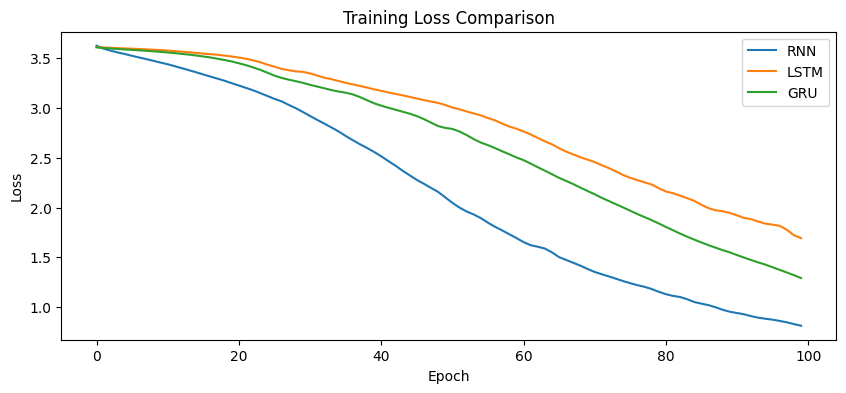

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [ ]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [ ]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning models models artificial meaningful meaningful
GRU : deep learning models predict the next next


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ***Task 1 : Replace corpus with your own paragraph***

In [ ]:
corpus = '''
Machine learning is one of the most important fields of artificial intelligence. It enables computers to learn from data and improve their performance without being explicitly programmed. Machine learning algorithms are widely used in healthcare, finance, education, and many other industries to solve real-world problems.

Deep learning is a subset of machine learning that uses artificial neural networks with multiple hidden layers. These networks are capable of learning complex patterns from large datasets and have achieved remarkable success in image classification, speech recognition, natural language processing, and recommendation systems.

Natural language processing focuses on enabling computers to understand, interpret, and generate human language. Applications of natural language processing include machine translation, text summarization, sentiment analysis, question answering, and conversational chatbots.

Recurrent neural networks are designed to process sequential data such as text, speech, and time series. Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU) networks improve upon traditional recurrent neural networks by reducing the vanishing gradient problem and capturing long-term dependencies more effectively.

Artificial intelligence continues to transform industries by automating repetitive tasks, supporting data-driven decision making, and creating intelligent systems that assist people in their everyday lives. As research advances, AI is expected to play an even greater role in science, medicine, business, and education.
'''
print(corpus)


Machine learning is one of the most important fields of artificial intelligence. It enables computers to learn from data and improve their performance without being explicitly programmed. Machine learning algorithms are widely used in healthcare, finance, education, and many other industries to solve real-world problems.

Deep learning is a subset of machine learning that uses artificial neural networks with multiple hidden layers. These networks are capable of learning complex patterns from large datasets and have achieved remarkable success in image classification, speech recognition, natural language processing, and recommendation systems.

Natural language processing focuses on enabling computers to understand, interpret, and generate human language. Applications of natural language processing include machine translation, text summarization, sentiment analysis, question answering, and conversational chatbots.

Recurrent neural networks are designed to process sequential data such 

# 📚 Tasks 2, 3 & 4: Increase the Embedding Dimension, Increase the Epochs to 200, and Change Hidden Units from 64 to 128

# **Model 1 : Vanila RNN**

In [ ]:
rnn_model1 = Sequential([
    Embedding(total_words, 64), # Task 2: Increased from 32 to 64
    SimpleRNN(128),              # Task 4: Changed from 64 to 128
    Dense(total_words, activation='softmax')
])

rnn_model1.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Task 3: Increased epochs from 100 to 200
rnn_history1 = rnn_model1.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# **Model 2 : LSTM Model**

In [ ]:
lstm_model1 = Sequential([
    Embedding(total_words, 64),   # Task 2: Increased from 32 to 64
    LSTM(128),                    # Task 4: Changed from 64 to 128
    Dense(total_words, activation='softmax')
])

lstm_model1.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Task 3: Increased epochs from 100 to 200
lstm_history1 = lstm_model1.fit(X, y, epochs=200, verbose=0)

print("LSTM training completed")

LSTM training completed


# **Model 3 : GRU**

In [ ]:
gru_model1 = Sequential([
    Embedding(total_words, 64), # Task 2: Increased from 32 to 64
    GRU(128),                    # Task 4: Changed from 64 to 128
    Dense(total_words, activation='softmax')
])

gru_model1.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Task 3: Increased epochs from 100 to 200
gru_history1 = gru_model1.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


# **Compare Training Loss**

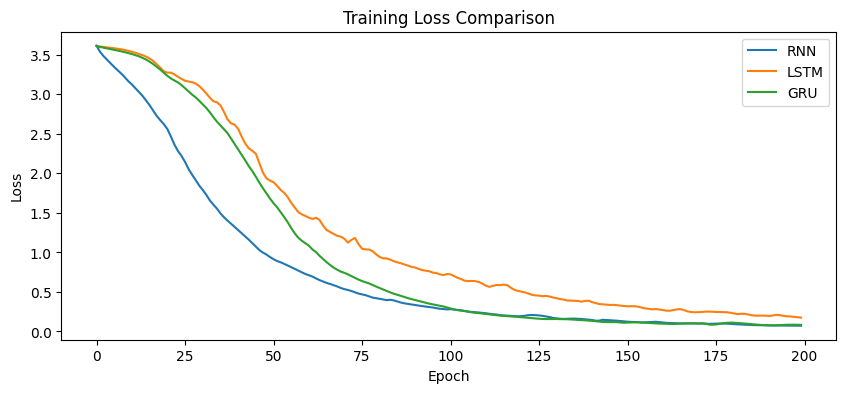

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history1.history['loss'], label='RNN')
plt.plot(lstm_history1.history['loss'], label='LSTM')
plt.plot(gru_history1.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ***Task 5 : Generate 10 words instead of 5***

In [ ]:
print("RNN :", generate_text(rnn_model1, "machine learning", 10))
print("LSTM:", generate_text(lstm_model1, "machine learning", 10))
print("GRU :", generate_text(gru_model1, "machine learning", 10))

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**